# Mood, Weather, and Productivity Analysis

This notebook explores the relationship between daily mood, productivity, sleep, stress, outdoor time, and weather perception.

The goal is not only to build a model, but also to understand the dataset step by step.

## 1. Import Libraries

I first import the libraries that will be used for data analysis, visualization, statistical testing, and simple machine learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

## 2. Load the Dataset

The dataset is stored in the `data` folder. Since the file uses semicolons as separators, I use `sep=";"` while reading it.

In [ ]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv("data_synthetic.csv", sep=";")

,person_id,day,mood,productivity,energy,sleep_hours,negative_event,stress,outdoor_time,weather_feeling
0,1,1,4,2,3,6.8,0,4,3,3
1,1,2,3,1,2,7.3,0,4,0,3
2,1,3,4,3,3,7.1,1,1,2,1
3,1,4,3,2,3,8.0,1,3,1,1
4,1,5,3,2,2,7.5,1,4,2,1


## 3. First Look at the Data

Here, I check the dataset size, column names, missing values, and basic descriptive statistics.

In [3]:
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (210, 10)

Column names:
['person_id', 'day', 'mood', 'productivity', 'energy', 'sleep_hours', 'negative_event', 'stress', 'outdoor_time', 'weather_feeling']

Missing values:
person_id          0
day                0
mood               0
productivity       0
energy             0
sleep_hours        0
negative_event     0
stress             0
outdoor_time       0
weather_feeling    0
dtype: int64


In [4]:
df.describe().round(2)

,person_id,day,mood,productivity,energy,sleep_hours,negative_event,stress,outdoor_time,weather_feeling
count,210.00,210.00,210.00,210.00,210.00,210.00,210.00,210.00,210.00,210.00
mean,8.00,7.50,3.80,2.75,3.15,7.34,0.36,2.34,1.58,2.54
std,4.33,4.04,0.82,0.75,0.98,1.02,0.48,0.95,1.04,1.03
min,1.00,1.00,2.00,1.00,1.00,4.50,0.00,1.00,0.00,1.00
25%,4.00,4.00,3.00,2.00,3.00,6.70,0.00,2.00,1.00,2.00
50%,8.00,7.50,4.00,3.00,3.00,7.40,0.00,2.00,2.00,3.00
75%,12.00,11.00,4.00,3.00,4.00,8.07,1.00,3.00,2.00,3.00
max,15.00,14.00,5.00,4.00,5.00,10.00,1.00,5.00,5.00,5.00


### Interpretation

The dataset includes daily observations about mood, productivity, energy, sleep, stress, outdoor time, and weather perception.

There are no missing values in the dataset, so no imputation or row deletion is needed at this stage.

## 4. Distributions of Main Variables

I plot the distributions to see how the values are spread across the dataset.

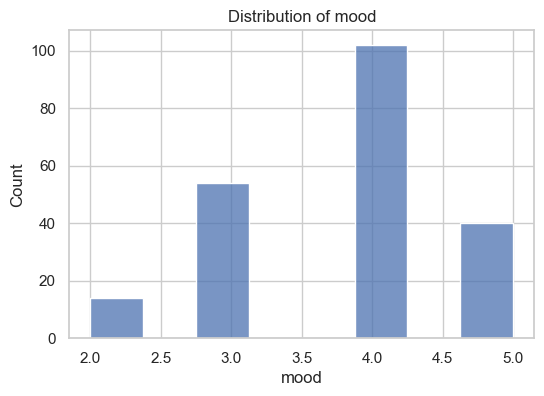

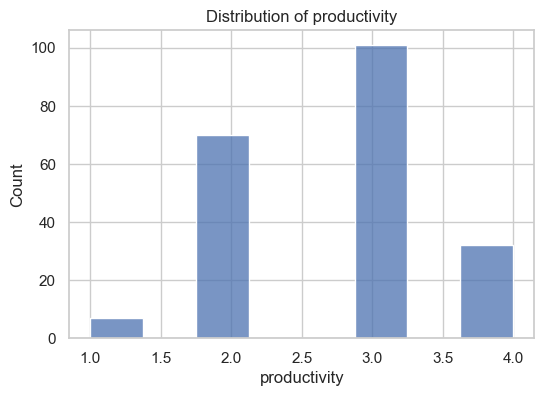

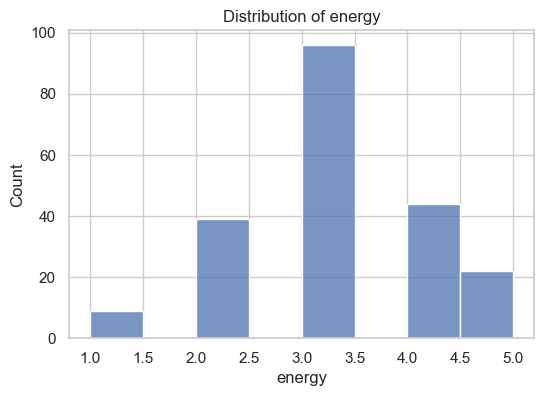

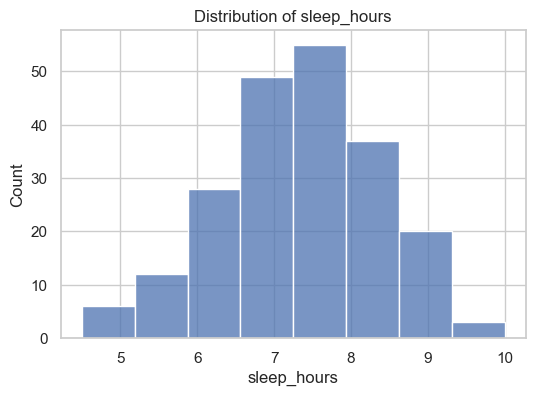

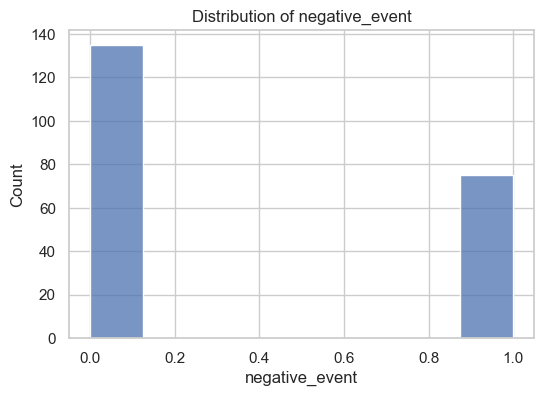

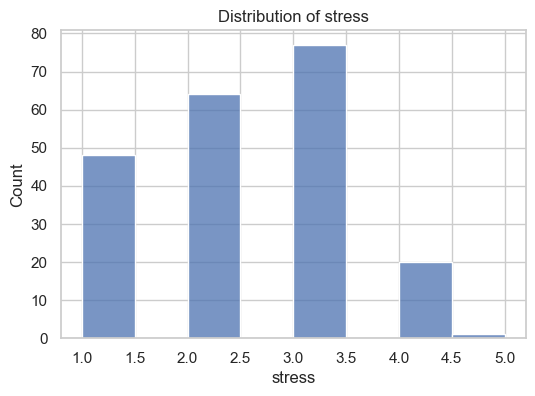

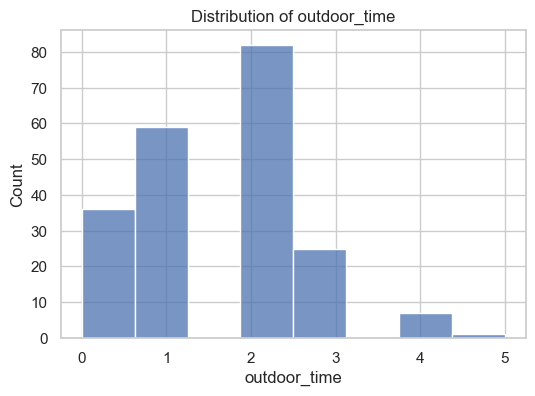

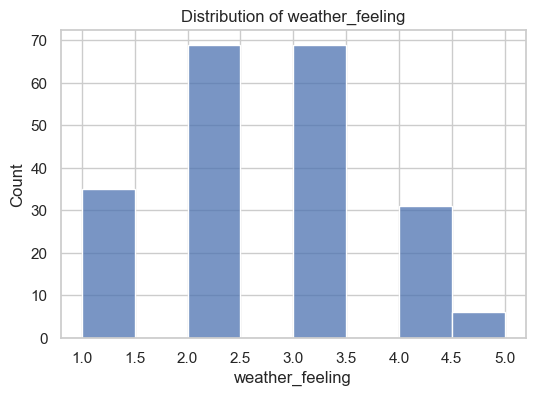

In [5]:
columns_to_plot = ["mood", "productivity", "energy", "sleep_hours",
                   "negative_event", "stress", "outdoor_time", "weather_feeling"]

for col in columns_to_plot:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], bins=8)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

### Interpretation

The variables are mostly measured on small rating scales, so the distributions are not very smooth. Still, they give a general idea about the frequency of different mood, stress, productivity, and weather perception levels.

## 5. Relationship Between Variables

In this part, I visualize some relationships that are directly related to the project question.

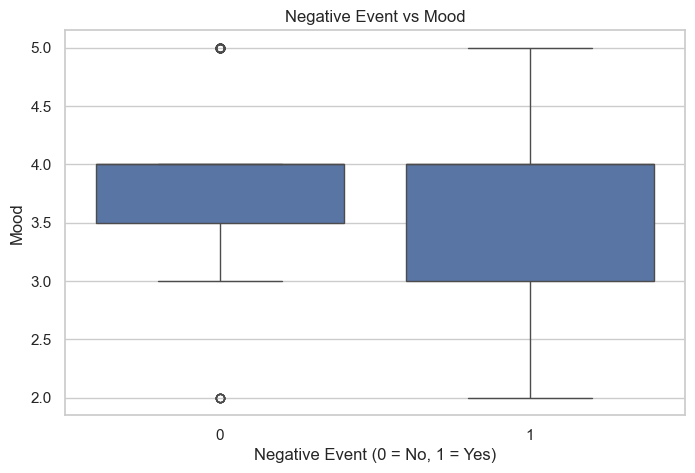

In [6]:
sns.boxplot(x=df["negative_event"], y=df["mood"])
plt.title("Negative Event vs Mood")
plt.xlabel("Negative Event (0 = No, 1 = Yes)")
plt.ylabel("Mood")
plt.show()

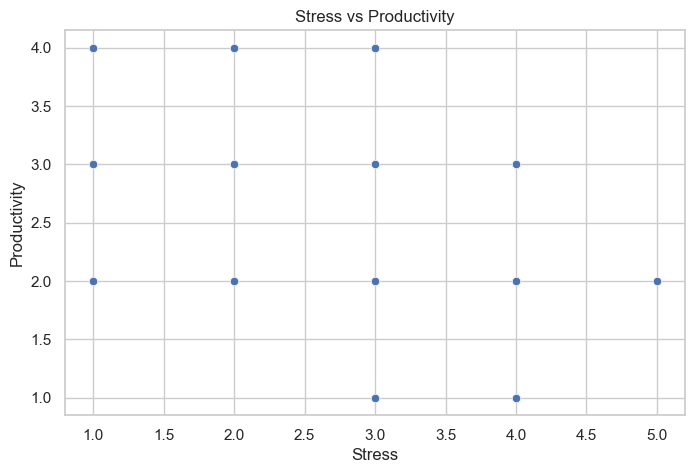

In [7]:
sns.scatterplot(x=df["stress"], y=df["productivity"])
plt.title("Stress vs Productivity")
plt.xlabel("Stress")
plt.ylabel("Productivity")
plt.show()

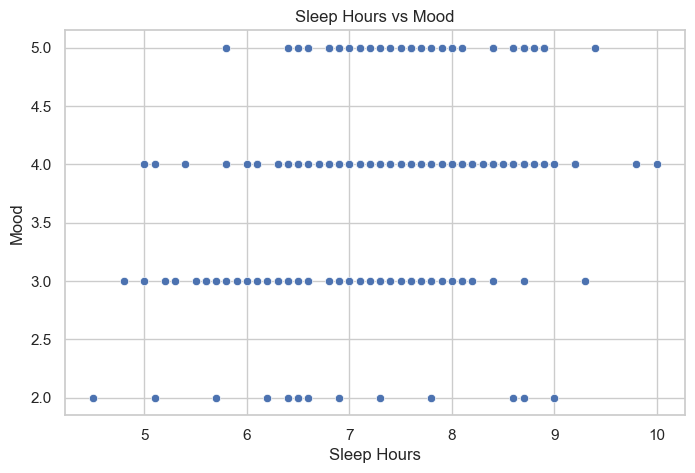

In [8]:
sns.scatterplot(x=df["sleep_hours"], y=df["mood"])
plt.title("Sleep Hours vs Mood")
plt.xlabel("Sleep Hours")
plt.ylabel("Mood")
plt.show()

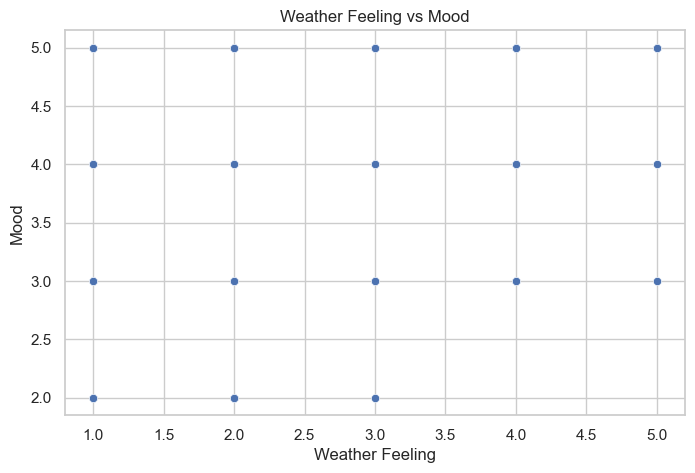

In [9]:
sns.scatterplot(x=df["weather_feeling"], y=df["mood"])
plt.title("Weather Feeling vs Mood")
plt.xlabel("Weather Feeling")
plt.ylabel("Mood")
plt.show()

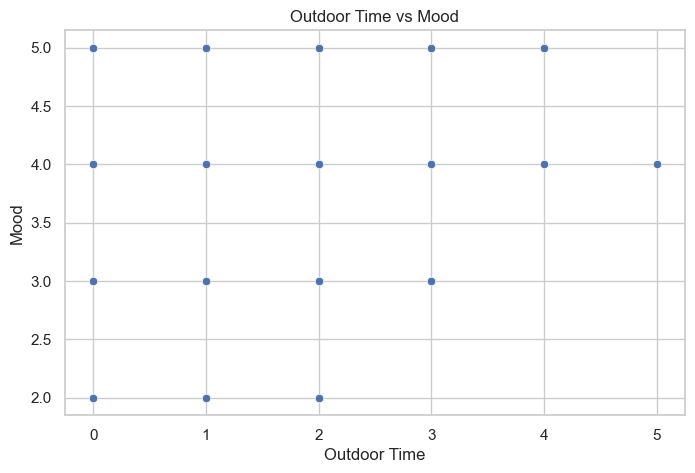

In [10]:
sns.scatterplot(x=df["outdoor_time"], y=df["mood"])
plt.title("Outdoor Time vs Mood")
plt.xlabel("Outdoor Time")
plt.ylabel("Mood")
plt.show()

### Initial Observations

- Mood seems lower on days with negative events.
- Higher stress appears to be related to lower productivity.
- Sleep, outdoor time, and weather feeling seem to have positive relationships with mood.

These are only visual observations, so I continue with correlation analysis and hypothesis testing.

## 6. Correlation Matrix

The correlation matrix helps summarize the direction and strength of relationships between numerical variables.

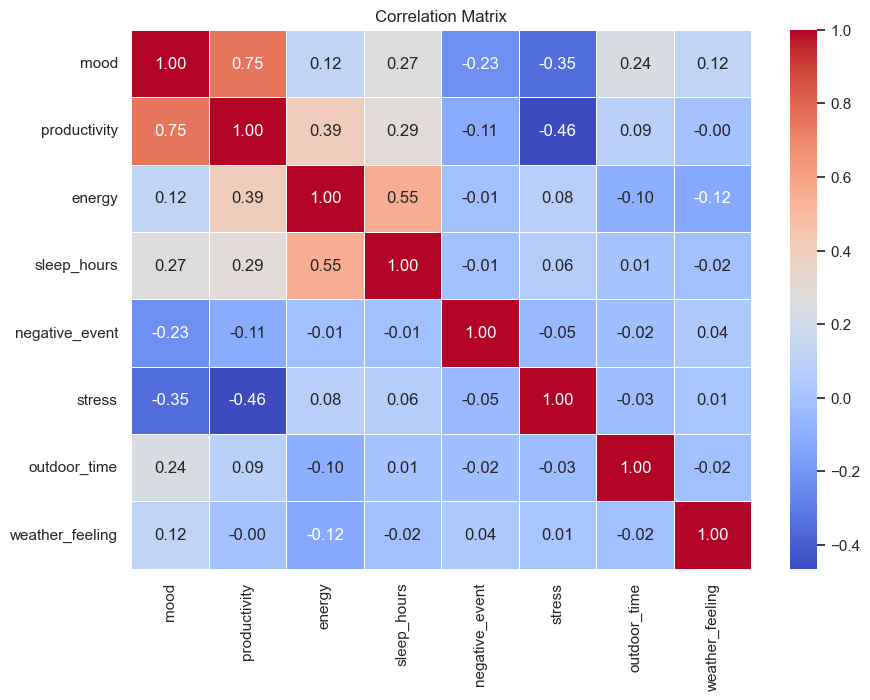

In [11]:
plt.figure(figsize=(10, 7))
corr = df.drop(columns=["person_id", "day"]).corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm", linewidths=0.5, fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

### Correlation Analysis Findings

Based on the correlation matrix:

- Mood and productivity appear positively related.
- Sleep hours are positively related to mood and energy.
- Stress has a negative relationship with productivity and mood.
- Negative events are associated with lower mood scores.
- Weather perception and outdoor time also show positive relationships with mood.

## 7. Hypothesis Testing

I use simple statistical tests to check whether some of the observed patterns are statistically meaningful.

### Hypothesis Test 1: Negative Event and Mood

- H0: Mood is the same on days with and without negative events.
- H1: Mood is different on days with and without negative events.

In [12]:
mood_no_event = df[df["negative_event"] == 0]["mood"]
mood_event = df[df["negative_event"] == 1]["mood"]

t_stat, p_value = stats.ttest_ind(mood_no_event, mood_event)

print("Mean mood without negative event:", round(mood_no_event.mean(), 2))
print("Mean mood with negative event:", round(mood_event.mean(), 2))
print("t-statistic:", round(t_stat, 3))
print("p-value:", round(p_value, 4))

if p_value < 0.05:
    print("Result: Reject H0. Negative events are related to mood.")
else:
    print("Result: Fail to reject H0.")

Mean mood without negative event: 3.94
Mean mood with negative event: 3.55
t-statistic: 3.408
p-value: 0.0008
Result: Reject H0. Negative events are related to mood.


### Hypothesis Test 2: Stress and Productivity

- H0: Stress and productivity are not related.
- H1: Stress and productivity are related.

In [13]:
corr, p_value = stats.pearsonr(df["stress"], df["productivity"])

print("Correlation:", round(corr, 3))
print("p-value:", round(p_value, 4))

if p_value < 0.05:
    print("Result: Reject H0. Stress and productivity are significantly related.")
else:
    print("Result: Fail to reject H0.")

Correlation: -0.465
p-value: 0.0
Result: Reject H0. Stress and productivity are significantly related.


### Hypothesis Test 3: Sleep and Mood

- H0: Sleep duration and mood are not related.
- H1: Sleep duration and mood are related.

In [14]:
corr, p_value = stats.pearsonr(df["sleep_hours"], df["mood"])

print("Correlation:", round(corr, 3))
print("p-value:", round(p_value, 4))

if p_value < 0.05:
    print("Result: Reject H0. Sleep duration and mood are significantly related.")
else:
    print("Result: Fail to reject H0.")

Correlation: 0.271
p-value: 0.0001
Result: Reject H0. Sleep duration and mood are significantly related.


## 8. Simple Machine Learning Model

For the machine learning part, I create a binary target variable:

- `1` = high mood, if mood is 4 or 5
- `0` = lower mood, if mood is below 4

Then I use a simple logistic regression model.

In [15]:
df["high_mood"] = (df["mood"] >= 4).astype(int)

features = ["productivity", "energy", "sleep_hours", "negative_event",
            "stress", "outdoor_time", "weather_feeling"]

X = df[features]
y = df["high_mood"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression()
model.fit(X_train_scaled, y_train)

predictions = model.predict(X_test_scaled)

print("Accuracy:", round(accuracy_score(y_test, predictions), 3))
print("\nClassification Report:")
print(classification_report(y_test, predictions))

Accuracy: 0.833

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.79      0.76        14
           1       0.89      0.86      0.87        28

    accuracy                           0.83        42
   macro avg       0.81      0.82      0.82        42
weighted avg       0.84      0.83      0.83        42



### Confusion Matrix

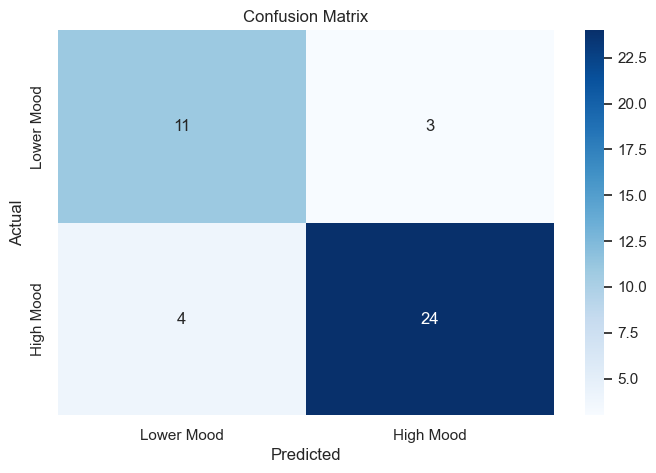

In [16]:
cm = confusion_matrix(y_test, predictions)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Lower Mood", "High Mood"],
            yticklabels=["Lower Mood", "High Mood"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Model Coefficients

The coefficients help show which variables are positively or negatively related to the probability of having a high mood.

In [17]:
coef_table = pd.DataFrame({
    "feature": features,
    "coefficient": model.coef_[0]
}).sort_values("coefficient", ascending=False)

coef_table

,feature,coefficient
0,productivity,2.316174
2,sleep_hours,0.619111
5,outdoor_time,0.445008
6,weather_feeling,0.156598
4,stress,-0.205041
3,negative_event,-0.478262
1,energy,-0.872987


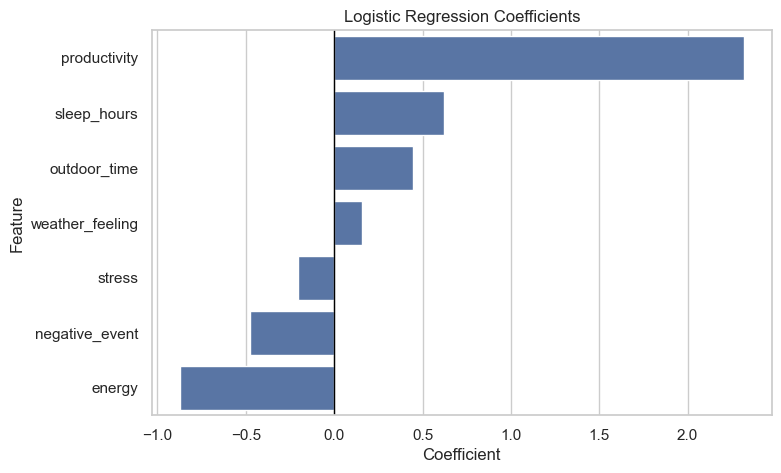

In [18]:
sns.barplot(data=coef_table, x="coefficient", y="feature")
plt.axvline(0, color="black", linewidth=1)
plt.title("Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.show()

### Final Insights

- Sleep duration, stress, and outdoor activity are associated with mood levels.
- Negative events generally reduce mood scores.
- The machine learning model achieved moderate performance in predicting high mood.